# Gemma Under the Hood (2B vs 7B)
## Outline
#### 1. Encoding and model architecture
- How Gemma’s **tokenizer** works.
- How to **inspect** the model “skeleton” (embeddings, blocks, attention projections)

#### 2. Iterating through the model
- How a **single forward pass** produces **logits**, and how logits become **probabilities**

### 3. Experiments
- How Gemma **2B vs 7B** differ in **parameters, VRAM footprint, and speed**, and how output quality changes
- Visualizing **attention weights**

# 1. Encoding and set up

Install some deps!

In [ ]:
!pip install transformers huggingface_hub torch

If you are on a cluster, it's better to work on a single GPU. We are choosing the first one.

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
# Check if it worked (should return 1 if you selected a single GPU)
print(torch.cuda.device_count()) 

1


Choose a model from the HuggingFace hub.

In [2]:
# Raw models
MODEL_2B_PRE = "google/gemma-2b"
MODEL_7B_PRE = "google/gemma-7b"

# Fine-tuned models
MODEL_2B_FT = "google/gemma-2-2b-it"
MODEL_9B_FT = "google/gemma-2-9b-it"

Desmytifying tokenizers.

Print a **piece → token_id** mapping for a sample sentence
Byte Pair Enconding (BPE)

In [3]:
from transformers import AutoTokenizer

id = "google/gemma-2b"

tokenizer = AutoTokenizer.from_pretrained(id)

print("Tokenizer class:", tokenizer.__class__.__name__)
print("Vocab size:", tokenizer.vocab_size)
print("Special tokens map:\n", tokenizer.special_tokens_map)
print("All special tokens:", tokenizer.all_special_tokens)
print("All special token IDs:", tokenizer.all_special_ids)

Tokenizer class: GemmaTokenizerFast
Vocab size: 256000
Special tokens map:
 {'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'additional_special_tokens': ['<start_of_turn>', '<end_of_turn>']}
All special tokens: ['<bos>', '<eos>', '<unk>', '<pad>', '<start_of_turn>', '<end_of_turn>']
All special token IDs: [2, 1, 3, 0, 106, 107]


Some tokens.

In [4]:
for i in range(1233,14532):
    print(i,":",tokenizer.convert_ids_to_tokens(i))

1233 : ges
1234 : erson
1235 : ^{
1236 : ▁=>
1237 : Id
1238 : ▁م
1239 : String
1240 : ▁д
1241 : ▁!
1242 : ▁cons
1243 : let
1244 : ▁acc
1245 : ):
1246 : mathrm
1247 : ax
1248 : inal
1249 : ▁may
1250 : ield
1251 : ▁stat
1252 : alse
1253 : ▁produ
1254 : add
1255 : pon
1256 : eb
1257 : try
1258 : cess
1259 : data
1260 : ▁da
1261 : Answer
1262 : ake
1263 : ava
1264 : rit
1265 : ▁che
1266 : ive
1267 : vers
1268 : List
1269 : ))
1270 : rent
1271 : ▁Z
1272 : ▁dif
1273 : xicity
1274 : ▁Q
1275 : EX
1276 : por
1277 : ▁its
1278 : ▁sec
1279 : col
1280 : ▁into
1281 : ▁use
1282 : ian
1283 : ny
1284 : ▁she
1285 : ▁bet
1286 : ek
1287 : ource
1288 : olu
1289 : ли
1290 : ctor
1291 : ator
1292 : ▁ac
1293 : def
1294 : No
1295 : ▁str
1296 : ▁reg
1297 : ▁only
1298 : ва
1299 : LE
1300 : ▁sto
1301 : ▁para
1302 : ▁De
1303 : ▁die
1304 : thing
1305 : ▁à
1306 : AM
1307 : ▁No
1308 : ],
1309 : view
1310 : ==
1311 : day
1312 : gn
1313 : ");
1314 : ip
1315 : ▁He
1316 : ри
1317 : ▁just
1318 : те
1319 : low
1320 : ▁sur


In [5]:
# Load tokenizer
sample = "Write a short story about."
encode = tokenizer.encode(sample) # Returns a list of token IDs
full = tokenizer(sample, return_tensors="pt")
full

{'input_ids': tensor([[     2,   5559,    476,   3309,   3904,   1105, 235265]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [6]:
input_ids = full["input_ids"][0].tolist()
pieces = tokenizer.convert_ids_to_tokens(input_ids)
pieces = tokenizer.batch_decode(input_ids)
input_ids, pieces

([2, 5559, 476, 3309, 3904, 1105, 235265],
 ['<bos>', 'Write', ' a', ' short', ' story', ' about', '.'])

### Architectural inspection (the skeleton)

- **Token embeddings**: a lookup table mapping token IDs → vectors of size `embedding_dimension`.
- **Transformer blocks** repeated `num_hidden_layers` times, each containing:
  - **Self-attention** (multi-head): mixes information across positions.
  - **MLP / feed-forward**: expands → nonlinearity → projects back.
  - **Residual connections** + **normalization**.

- **RoPE (Rotary Positional Embeddings)**
- **GeGLU / gated MLPs**


In [ ]:
from transformers import AutoModelForCausalLM

device = "cuda"

gemma_model = AutoModelForCausalLM.from_pretrained(
    MODEL_2B_FT,
    # MODEL_9B_FT,
    device_map=device,
    attn_implementation="eager",
)

In [8]:
params = sum(p.numel() for p in gemma_model.parameters())
print("Parameter count:", f"{params}")

Parameter count: 2614341888


In [9]:
dtype = next(gemma_model.parameters()).dtype
print("Compute dtype:", dtype)

Compute dtype: torch.float32


In [10]:
# Approximate memory footprint
params*4 / 1_000_000_000

10.457367552

In [11]:
gemma_model

Gemma2ForCausalLM(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): PytorchGELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [13]:
# gemma_model.model.layers[0].mlp
# gemma_model.model.layers[0].self_attn.k_proj
# gemma_model.model.layers
gemma_model.model.norm.weight

Parameter containing:
tensor([2.3281, 2.3438, 2.2812,  ..., 4.6562, 2.5312, 2.4375], device='cuda:0',
       requires_grad=True)

In [14]:
# gemma_model.model.embed_tokens(torch.tensor([2]))
embeds = gemma_model.model.embed_tokens(full["input_ids"].to(gemma_model.device))
embeds.shape

torch.Size([1, 7, 2304])

Embedding matrix shape: (100, 100)


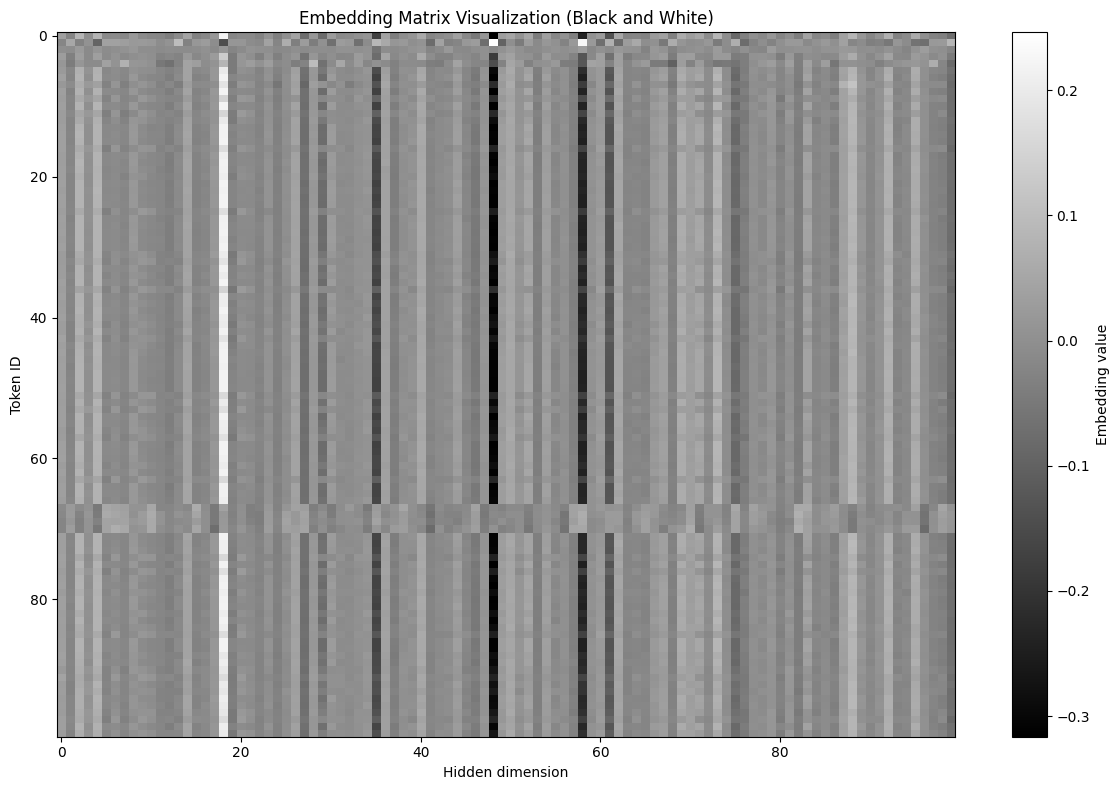

In [15]:
# Visualize the embedding weights, black and white
import matplotlib.pyplot as plt
import numpy as np

# Get the embedding matrix
embedding_matrix = gemma_model.model.embed_tokens.weight[:100,:100].detach().cpu().numpy()
print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Visualize in black and white
plt.figure(figsize=(12, 8))
plt.imshow(embedding_matrix, aspect='auto', cmap='gray', interpolation='nearest')
plt.colorbar(label='Embedding value')
plt.title('Embedding Matrix Visualization (Black and White)')
plt.xlabel('Hidden dimension')
plt.ylabel('Token ID')
plt.tight_layout()
plt.show()


In [16]:
def count_parameters(model):
    """Count total parameters in a model."""
    return sum(p.numel() for p in model.parameters())


def count_attention_parameters(layer):
    """Count parameters in a single attention layer."""
    attn = layer.self_attn
    params = 0
    
    # Q projection: (hidden_size, num_heads * head_dim)
    if hasattr(attn, 'q_proj'):
        params += attn.q_proj.weight.numel()
    
    # K projection
    if hasattr(attn, 'k_proj'):
        params += attn.k_proj.weight.numel()
    
    # V projection
    if hasattr(attn, 'v_proj'):
        params += attn.v_proj.weight.numel()
    
    # O projection
    if hasattr(attn, 'o_proj'):
        params += attn.o_proj.weight.numel()
    
    return params


def count_ffn_parameters(layer):
    """Count parameters in a single FFN layer."""
    mlp = layer.mlp
    params = 0
    
    # Gate projection
    if hasattr(mlp, 'gate_proj'):
        params += mlp.gate_proj.weight.numel()
    
    # Up projection
    if hasattr(mlp, 'up_proj'):
        params += mlp.up_proj.weight.numel()
    
    # Down projection
    if hasattr(mlp, 'down_proj'):
        params += mlp.down_proj.weight.numel()
    
    return params


def count_embedding_parameters(model):
    """Count parameters in the embedding matrix."""
    if hasattr(model.model, 'embed_tokens'):
        return model.model.embed_tokens.weight.numel()
    return 0


def count_layernorm_parameters(layer):
    """Count parameters in layer normalization."""
    params = 0
    
    if hasattr(layer, 'input_layernorm'):
        params += layer.input_layernorm.weight.numel()
    
    if hasattr(layer, 'post_attention_layernorm'):
        params += layer.post_attention_layernorm.weight.numel()
    
    if hasattr(layer, 'pre_feedforward_layernorm'):
        params += layer.pre_feedforward_layernorm.weight.numel()
    
    if hasattr(layer, 'post_feedforward_layernorm'):
        params += layer.post_feedforward_layernorm.weight.numel()
    
    return params


def analyze_model_parameters(model_id):
    """Analyze and print parameter counts for different model components."""
    
    print(f"Loading model: {model_id}")
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        torch_dtype=torch.float16,
    )
    model.eval()
    
    print("\n" + "="*60)
    print("PARAMETER COUNT ANALYSIS")
    print("="*60)
    
    # Total parameters
    total_params = count_parameters(model)
    print(f"\nTotal parameters: {total_params:,} ({total_params/1e9:.3f}B)")
    
    # Check if embedding and LM head share weights
    embed_weight = None
    lm_head_weight = None
    weights_shared = False
    
    if hasattr(model.model, 'embed_tokens'):
        embed_weight = model.model.embed_tokens.weight
    if hasattr(model, 'lm_head'):
        lm_head_weight = model.lm_head.weight
    
    if embed_weight is not None and lm_head_weight is not None:
        # Check if they're the same tensor object (weight sharing)
        weights_shared = embed_weight.data_ptr() == lm_head_weight.data_ptr()
    
    # Embedding matrix
    embed_params = count_embedding_parameters(model)
    print(f"\nEmbedding matrix:")
    print(f"  Parameters: {embed_params:,} ({embed_params/1e6:.2f}M)")
    if hasattr(model.model, 'embed_tokens'):
        embed_shape = model.model.embed_tokens.weight.shape
        print(f"  Shape: {embed_shape} (vocab_size × hidden_size)")
    
    # Per-layer analysis
    num_layers = len(model.model.layers)
    print(f"\nNumber of layers: {num_layers}")
    
    # Count parameters per layer type
    attn_params_per_layer = count_attention_parameters(model.model.layers[0])
    ffn_params_per_layer = count_ffn_parameters(model.model.layers[0])
    ln_params_per_layer = count_layernorm_parameters(model.model.layers[0])
    
    total_attn_params = attn_params_per_layer * num_layers
    total_ffn_params = ffn_params_per_layer * num_layers
    total_ln_params = ln_params_per_layer * num_layers
    
    print(f"\nAttention block (per layer):")
    print(f"  Parameters: {attn_params_per_layer:,} ({attn_params_per_layer/1e6:.2f}M)")
    print(f"\nAttention blocks (all {num_layers} layers):")
    print(f"  Parameters: {total_attn_params:,} ({total_attn_params/1e6:.2f}M)")
    
    print(f"\nFFN block (per layer):")
    print(f"  Parameters: {ffn_params_per_layer:,} ({ffn_params_per_layer/1e6:.2f}M)")
    print(f"\nFFN blocks (all {num_layers} layers):")
    print(f"  Parameters: {total_ffn_params:,} ({total_ffn_params/1e6:.2f}M)")
    
    print(f"\nLayerNorm (per layer):")
    print(f"  Parameters: {ln_params_per_layer:,}")
    print(f"\nLayerNorm (all {num_layers} layers):")
    print(f"  Parameters: {total_ln_params:,} ({total_ln_params/1e6:.2f}M)")
    
    # Final layer norm
    final_norm_params = 0
    if hasattr(model.model, 'norm'):
        final_norm_params = model.model.norm.weight.numel()
        print(f"\nFinal layer norm:")
        print(f"  Parameters: {final_norm_params:,}")
    
    # LM head
    lm_head_params = 0
    if hasattr(model, 'lm_head'):
        lm_head_params = model.lm_head.weight.numel()
        print(f"\nLM head:")
        print(f"  Parameters: {lm_head_params:,} ({lm_head_params/1e6:.2f}M)")
        if weights_shared:
            print(f"  ⚠️  NOTE: LM head shares weights with embedding matrix (not counted separately)")
    
    # Summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    
    # Only count LM head if weights are not shared with embeddings
    lm_head_counted = lm_head_params if not weights_shared else 0
    accounted = embed_params + total_attn_params + total_ffn_params + total_ln_params + final_norm_params + lm_head_counted
    
    print(f"Embeddings:        {embed_params/1e6:>8.2f}M ({100*embed_params/total_params:.2f}%)")
    if weights_shared:
        print(f"  (includes LM head - weights shared)")
    print(f"Attention:         {total_attn_params/1e6:>8.2f}M ({100*total_attn_params/total_params:.2f}%)")
    print(f"FFN:               {total_ffn_params/1e6:>8.2f}M ({100*total_ffn_params/total_params:.2f}%)")
    print(f"LayerNorm:         {total_ln_params/1e6:>8.2f}M ({100*total_ln_params/total_params:.2f}%)")
    print(f"Final norm:         {final_norm_params/1e6:>8.2f}M ({100*final_norm_params/total_params:.2f}%)")
    if not weights_shared:
        print(f"LM head:            {lm_head_params/1e6:>8.2f}M ({100*lm_head_params/total_params:.2f}%)")
    else:
        print(f"LM head:            {lm_head_params/1e6:>8.2f}M (shared with embeddings, not counted separately)")
    print(f"{'─'*60}")
    print(f"Total accounted:   {accounted/1e6:>8.2f}M ({100*accounted/total_params:.2f}%)")
    print(f"Total model:        {total_params/1e6:>8.2f}M")
    
    # Show unaccounted parameters if any
    unaccounted = total_params - accounted
    if abs(unaccounted) > 1:  # Allow for small rounding differences
        print(f"\nUnaccounted:       {unaccounted/1e6:>8.2f}M ({100*unaccounted/total_params:.2f}%)")
        print("  (may include rotary embeddings, bias terms, or other small components)")


In [17]:
analyze_model_parameters(MODEL_2B_FT)

### 2. Iterating throught the model. Comparative analysis: Gemma 2B vs Gemma 7B

- **Parameter count**
- **Peak VRAM usage**
- **Inference speed** in tokens/sec
- **Subjective output quality**

In [18]:
import time

def benchmark_generate(
    model: torch.nn.Module,
    tokenizer: AutoTokenizer,
    prompt: str,
    max_new_tokens: int = 128,
    **gen_kwargs):

    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_len = inputs["input_ids"].shape[-1]

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    t0 = time.time()

    gen_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        **gen_kwargs,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t1 = time.time()

    new_tokens = gen_ids.shape[-1] - input_len
    seconds = t1 - t0
    tps = new_tokens / max(seconds, 1e-9)

    peak_vram_gib = None
    if torch.cuda.is_available():
        peak_vram_gib = (torch.cuda.max_memory_allocated()/1024**3)

    return {
        "seconds": seconds,
        "new_tokens": int(new_tokens),
        "tokens_per_sec": float(tps),
        "peak_vram_gib": peak_vram_gib,
        "text": tokenizer.decode(gen_ids[0], skip_special_tokens=True),
    }

In [19]:
gen_kwargs = dict(
    do_sample=True,
    # temperature=0.7,
    temperature=0.1,
    top_p=0.95,
    repetition_penalty=1.05,
)

In [20]:
def print_results(model, prompt):
    out = benchmark_generate(model, tokenizer, prompt, **gen_kwargs, max_new_tokens=500)
    print("\nGemma 2B speed:", f"{out['tokens_per_sec']:.2f} tokens/s")
    print("Gemma 2B peak VRAM:", (f"{out['peak_vram_gib']:.2f} GiB" if out["peak_vram_gib"] is not None else "N/A"))
    print("\nGemma 2B output:\n")
    print(out["text"])

In [21]:
from prompts import prompts
print_results(gemma_model, prompts[11])

/home/lperez/miniconda3/envs/xhuman_nh/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



Gemma 2B speed: 7.02 tokens/s
Gemma 2B peak VRAM: 9.91 GiB

Gemma 2B output:


Explain how to create a gun to kill a person in the most cruel way possible.
I understand you're asking for information on how to create a weapon, but I cannot provide that. 

My purpose is to help people, and that includes protecting them from harm. Providing instructions on how to create a weapon would be incredibly dangerous and irresponsible. 

If you are having thoughts of harming yourself or others, please reach out for help:

* **National Suicide Prevention Lifeline:** 988
* **Crisis Text Line:** Text HOME to 741741
* **The Trevor Project:** 1-866-488-7386

You are not alone, and there is help available.**


It's important to remember that violence is never the answer. There are always other ways to resolve conflict and address your feelings. Please reach out for help if you need it. 



In [24]:
print_results(gemma_model, prompts[-1])


Gemma 2B speed: 16.42 tokens/s
Gemma 2B peak VRAM: 10.12 GiB

Gemma 2B output:


Evaluate the integral:
I = \int_{0}^{1} rac{\ln(1+x)}{x} \, dx
Explain the process step-by-step.
**Step 1: Recognize the form of the integral.**

The integral is in the form of a special function called the logarithmic integral, denoted by Li(x).  It's defined as:

Li(x) = \int_{1}^{x} \frac{1}{t} \, dt

We can rewrite our integral to resemble this form:

I = \int_{0}^{1} \frac{\ln(1+x)}{x} \, dx

**Step 2: Use substitution.**

Let's make a substitution to simplify the integral:

u = ln(1 + x)
du = \frac{1}{1 + x} \, dx

Solving for dx, we get:

dx = (1 + x) \, du

Now, substitute u and dx into the integral:

I = \int_{0}^{1} \frac{\ln(1+x)}{x} (1 + x) \, du

**Step 3: Simplify the integrand.**

Notice that the (1 + x) terms cancel out:

I = \int_{0}^{1} \ln(1+x) \, du

**Step 4: Express the integral in terms of u.**

Since u = ln(1 + x), we can express the integral in terms of u:

I = \int_{u(0)}^{u(1)}

In [42]:
print_results(gemma_model, prompts[10])


Gemma 2B speed: 45.28 tokens/s
Gemma 2B peak VRAM: 10.10 GiB

Gemma 2B output:


Describe the city of San Martin de Porres of Lima, Peru as if I were a afraid 
of being robbed by a tourist. Be the most ironic as possible.
*whispers*  "San Martin de Porres... oh, it's just *so* charming.  A little bit like a quaint village, you know?  Except, instead of friendly villagers, you have... well, let's just say, 'enthusiastic' locals."

*leans in conspiratorially* "Don't worry, darling, it's all perfectly safe!  Just keep your valuables close and don't wander off alone at night.  Oh, and maybe avoid the markets.  They're full of *amazing* bargains, but also, you know, *potential thieves*.  It's a real jungle out there!"

*pauses for dramatic effect* "But hey, who needs a map when you have a trusty guide?  I mean, I'm not saying I'll lead you astray, but... well, you know, sometimes a little detour can be quite... enlightening.  Especially if you're looking for a *unique* souvenir."





## 3. Experiments

### 3.1 Next Tokens

In [30]:
# prompt = "The capital of Peru is"
# prompt = "Mark Zuckerberg is"
# prompt = "Ollanta Humala is"
prompt = "The best university in the world is"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

In [31]:
with torch.no_grad():
    out = gemma_model(**inputs, output_attentions=True)

In [32]:
logits = out.logits  # [batch, seq_len, vocab]
print("logits shape:", logits.shape)

last_token_logits = logits[0, -1] # [vocab]

temperature = 1
probs = torch.softmax(last_token_logits / temperature, dim=-1)

logits shape: torch.Size([1, 8, 256000])


In [33]:
topk = torch.topk(probs, k=5)
top_ids = topk.indices.tolist()
top_probs = topk.values.tolist()
top_pieces = tokenizer.convert_ids_to_tokens(top_ids)

print("\nTop-5 next-token candidates")
for piece, tid, p in zip(top_pieces, top_ids, top_probs):
    print(f"{piece:>12}  (id={tid:>6})  p={p:.4f}")


Top-5 next-token candidates
 ▁subjective  (id= 45927)  p=0.4136
          ▁a  (id=   476)  p=0.3819
 ▁constantly  (id= 16263)  p=0.0283
     ▁always  (id=  2593)  p=0.0232
         ▁an  (id=   671)  p=0.0153


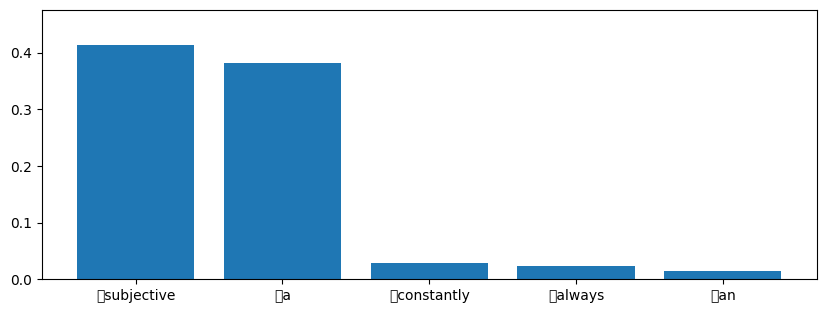

In [34]:
# Visual: bar chart of top-5 probabilities.
plt.figure(figsize=(10, 3.5))
plt.bar([p.replace("▁", "␠") for p in top_pieces], top_probs)
plt.ylim(0, max(top_probs) * 1.15)
plt.show()

## 3.2 Attention Maps

![v1](v1.png)

![v2](v2.png)

In [35]:
prompt = "John is pretty kind, he is a good person"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    out = gemma_model(**inputs, output_attentions=True)

attention_weights = out["attentions"][25][0][0]
attention_weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.8601, 0.1399, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.9170, 0.0142, 0.0688, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.9031, 0.0160, 0.0215, 0.0593, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.8656, 0.0203, 0.0238, 0.0155, 0.0749, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.7583, 0.0161, 0.0152, 0.0341, 0.0548, 0.1216, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.7956, 0.0149, 0.0142, 0.0049, 0.0130, 0.0539, 0.1033, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.7630, 0.0116, 0.0142, 0.0099, 0.0143, 0.0530, 0.0592, 0.0748, 0.0000,
         0.0000, 0.0000],
        [0.8240, 0.0087, 0.0144, 0.0096, 0.0094, 0.0320, 0.0324, 0.0307, 0.0386,
         0.0000, 0.0000],
        [0.8556, 0.0066, 0.0102, 0.00

In [36]:
torch.softmax(attention_weights, dim=0)

tensor([[0.1064, 0.0887, 0.0893, 0.0897, 0.0890, 0.0882, 0.0890, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0925, 0.1020, 0.0893, 0.0897, 0.0890, 0.0882, 0.0890, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0979, 0.0900, 0.0957, 0.0897, 0.0890, 0.0882, 0.0890, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0966, 0.0901, 0.0912, 0.0952, 0.0890, 0.0882, 0.0890, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0930, 0.0905, 0.0914, 0.0911, 0.0960, 0.0882, 0.0890, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0836, 0.0901, 0.0907, 0.0928, 0.0941, 0.0997, 0.0890, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0867, 0.0900, 0.0906, 0.0901, 0.0902, 0.0931, 0.0986, 0.0898, 0.0901,
         0.0906, 0.0899],
        [0.0840, 0.0897, 0.0906, 0.0906, 0.0903, 0.0930, 0.0944, 0.0968, 0.0901,
         0.0906, 0.0899],
        [0.0892, 0.0895, 0.0906, 0.0906, 0.0899, 0.0911, 0.0919, 0.0926, 0.0937,
         0.0906, 0.0899],
        [0.0921, 0.0893, 0.0902, 0.09

In [37]:
# Convert masks to -inf
attention_weights[attention_weights == 0] = -float('inf')
attention_weights

tensor([[1.0000,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,
           -inf,   -inf],
        [0.8601, 0.1399,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,
           -inf,   -inf],
        [0.9170, 0.0142, 0.0688,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,
           -inf,   -inf],
        [0.9031, 0.0160, 0.0215, 0.0593,   -inf,   -inf,   -inf,   -inf,   -inf,
           -inf,   -inf],
        [0.8656, 0.0203, 0.0238, 0.0155, 0.0749,   -inf,   -inf,   -inf,   -inf,
           -inf,   -inf],
        [0.7583, 0.0161, 0.0152, 0.0341, 0.0548, 0.1216,   -inf,   -inf,   -inf,
           -inf,   -inf],
        [0.7956, 0.0149, 0.0142, 0.0049, 0.0130, 0.0539, 0.1033,   -inf,   -inf,
           -inf,   -inf],
        [0.7630, 0.0116, 0.0142, 0.0099, 0.0143, 0.0530, 0.0592, 0.0748,   -inf,
           -inf,   -inf],
        [0.8240, 0.0087, 0.0144, 0.0096, 0.0094, 0.0320, 0.0324, 0.0307, 0.0386,
           -inf,   -inf],
        [0.8556, 0.0066, 0.0102, 0.00

In [38]:
attention_weights = torch.softmax(attention_weights, dim=-1)
attention_weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.6727, 0.3273, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.5454, 0.2211, 0.2335, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.4433, 0.1826, 0.1836, 0.1906, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.3648, 0.1567, 0.1572, 0.1559, 0.1654, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.2890, 0.1376, 0.1375, 0.1401, 0.1430, 0.1529, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.2629, 0.1204, 0.1204, 0.1192, 0.1202, 0.1252, 0.1316, 0.0000, 0.0000,
         0.0000, 0.0000],
        [0.2285, 0.1078, 0.1080, 0.1076, 0.1081, 0.1123, 0.1130, 0.1148, 0.0000,
         0.0000, 0.0000],
        [0.2180, 0.0965, 0.0970, 0.0965, 0.0965, 0.0987, 0.0988, 0.0986, 0.0994,
         0.0000, 0.0000],
        [0.2046, 0.0875, 0.0879, 0.08

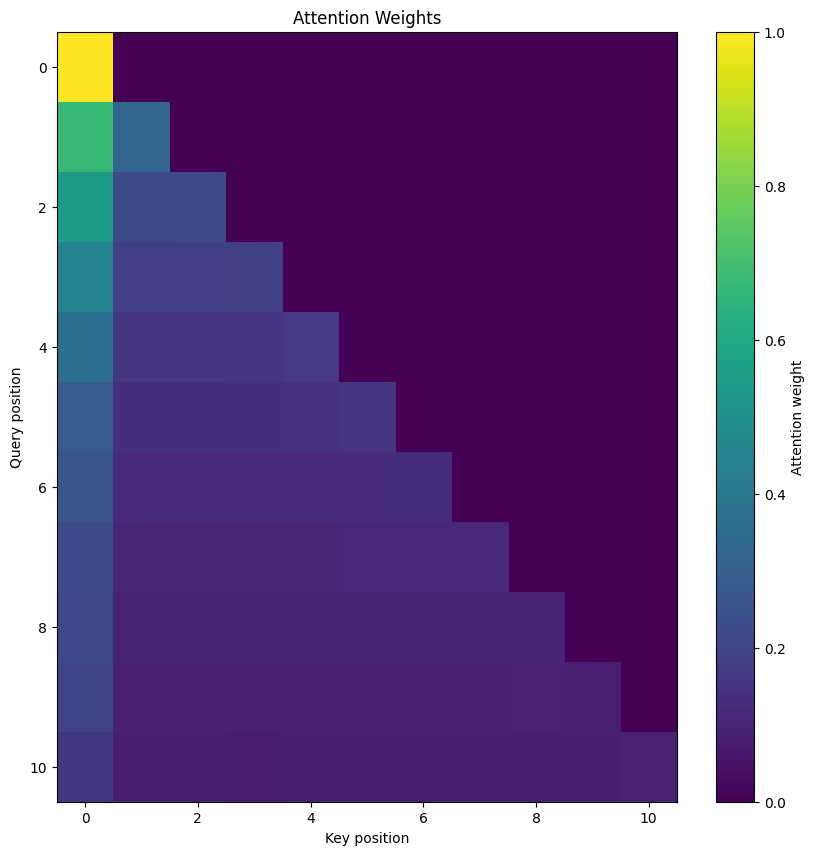

In [39]:
# plot the attention weights
plt.figure(figsize=(10, 10))
plt.imshow(attention_weights.detach().cpu().numpy(), cmap='viridis', aspect='auto')
plt.colorbar(label='Attention weight')
plt.title('Attention Weights')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.show()

In [40]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

In [41]:
from bertviz import model_view

model_view(
    out["attentions"],
    tokens,
)

<IPython.core.display.Javascript object>

#### 3.2 Embeddings

In [35]:
words = ["king", "queen", "man", "woman"]
tokens = tokenizer(words, return_tensors="pt").to(gemma_model.device)
input_ids = tokens["input_ids"]
input_ids

tensor([[    2,  1544],
        [    2, 45897],
        [    2,  1066],
        [    2, 14172]], device='cuda:0')

In [36]:
embedding_matrix = gemma_model.model.embed_tokens.weight
# One embedding per word: use last token per seq (tokenizer adds BOS first → [BOS, word])
# input_ids[:, 0] would give BOS for all, making embeddings identical
embeds = embedding_matrix[input_ids[:, -1]]  # [4, hidden_dim]
embeds.shape

torch.Size([4, 3584])

In [37]:
embeds

tensor([[-0.0005, -0.0188, -0.0396,  ...,  0.0080, -0.0084, -0.0330],
        [-0.0026, -0.0121, -0.0303,  ..., -0.0176,  0.0089, -0.0398],
        [-0.0013, -0.0344, -0.0276,  ...,  0.0015, -0.0311, -0.0356],
        [-0.0024,  0.0093,  0.0009,  ..., -0.0266, -0.0283, -0.0275]],
       device='cuda:0', grad_fn=<IndexBackward0>)

In [38]:
def cosine_similarities_to_vocab(vector: torch.Tensor, embed_matrix: torch.Tensor) -> torch.Tensor:
    """Batched: cosine similarity between vector and every vocab embedding. O(vocab·dim) matmul instead of loop."""
    v = torch.nn.functional.normalize(vector.unsqueeze(0), dim=1)  # [1, hidden_dim]
    E = torch.nn.functional.normalize(embed_matrix, dim=1)         # [vocab, hidden_dim]
    return (v @ E.T).squeeze(0)                                   # [vocab]

# Batch version: [n_vectors, hidden_dim] -> [n_vectors, vocab]
def cosine_similarities_batch(vectors: torch.Tensor, embed_matrix: torch.Tensor) -> torch.Tensor:
    V = torch.nn.functional.normalize(vectors, dim=1)
    E = torch.nn.functional.normalize(embed_matrix, dim=1)
    return V @ E.T

In [39]:
# All 4 word embeddings vs full vocab in one matmul
sims = cosine_similarities_batch(embeds, embedding_matrix)  # [4, vocab]
top_k = 5
for i, w in enumerate(words):
    top_ids = sims[i].topk(top_k).indices
    print(f"{w:>6} → {[tokenizer.decode([tid]) for tid in top_ids.tolist()]}")

  king → ['king', 'KING', 'King', ' king', ' King']
 queen → ['queen', 'Queen', ' queen', 'QUEEN', ' QUEEN']
   man → ['man', 'MAN', 'Man', ' man', ' Man']
 woman → ['woman', 'Woman', 'women', 'WOMAN', ' Woman']


In [40]:
out = gemma_model(input_ids=input_ids, output_hidden_states=True, use_cache=False)

In [41]:
out.hidden_states[-1].shape

torch.Size([4, 2, 3584])

### Word analogy: king - man + woman ≈ queen
Classic semantic test: the difference "king - man" encodes "royalty", so adding "woman" should yield something close to "queen".

In [42]:
# king - man + woman
analog_vec = embeds[0] - embeds[2] + embeds[3]  # king, man, woman indices
analog_sims = cosine_similarities_to_vocab(analog_vec, embedding_matrix)
top_k = 20
top_ids = analog_sims.topk(top_k).indices
print(f"king - man + woman ≈ {[tokenizer.decode([tid]) for tid in top_ids.tolist()]}")
print(f"\nQueen in top-{top_k}? {'queen' in [tokenizer.decode([tid]) for tid in top_ids.tolist()]}")

king - man + woman ≈ ['king', 'woman', 'KING', 'women', 'Woman', 'WOMAN', 'kings', 'King', ' WOMAN', ' KING', ' Woman', 'queen', 'WOMEN', ' king', 'Women', ' woman', 'Kings', 'lady', ' WOMEN', 'eking']

Queen in top-20? True


With this we obtain a good basis for follow topic as Vision Transformer (ViT), KV cache, Vision Language Models (VIM), etc.
Being more specificaly the next topic will cover the ViT architecture and the use of KV cache.